# Phytoplankton Phenology Study in the Northwest Atlantic Ocean

#### Import Python Libraries

In [189]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy
import pandas as pd
from shapely.ops import unary_union
import cartopy.feature as cfeature
import geopandas as gpd
from shapely.geometry import mapping
from shapely.geometry import Polygon
import rioxarray
import sys
sys.path.append(r'C:\Users\grace.davis\Documents\GitHub\RESOURCES\python')
import utilities
from utilities import get_prod_files
import cmocean
from matplotlib.colors import LogNorm
import cartopy.crs as crs
import statsmodels as sm
from statsmodels import nonparametric
from statsmodels.nonparametric import smoothers_lowess
import scipy
from scipy import signal
from scipy.signal import find_peaks
from scipy.signal import argrelextrema
from scipy.signal import savgol_filter
from scipy.integrate import trapezoid
from collections import Counter
import plotly.express as px

## Part 1: Bloom Detection Method Testing

### Threshold Method

#### Function for determining the climatological threshold value
Based on the climatological median, this function finds a certain percentage of that median and adds it to the median to get a threshold value for determining phytoplankton blooms
* Must include:
    * Threshold percentage = thld (thld=0.05 by default)
    * Path to climatology files = path (set to NES Annual Climatology 1997 - 2020 by default)

In [2]:
def threshold_value(thld = 0.1, path = None):
    """
    Calculates the threshold value for chlorophyll-a based on a median baseline provided by the regional climatology.

    If no file path is provided, the path defaults to grabbing and reading the annual climatology file for the Northeast Shelf (NES) region. 
    The threshold is calculated by finding the percentage above the climatological CHL median for each pixel in the region.

    Args:
        thld (float, optional): The fraction value of the percentage above the median. This value defaults to 0.1 (10%).
        path (str, optional): The path to netCDF file used to calculate the threshold value. Defaults to None.

    Returns:
        xarray.DataArray: A spatial array containing the threshold values for each coordinate based on the median CHL value
    """
    if path is None:
        file = get_prod_files('CHL',mapping='NES',period='ANNUAL') #finds path for the annual climatology file
        base_ds = xr.open_dataset(file[0]) #opens netCDF file
    else:
        base_ds = xr.open_dataset(path)
    median_CHL = base_ds.CHL_median #grabs CHL_median variable
    thld_value = median_CHL*(1+thld) #Sets threshold value per latitude and longitude point
    return thld_value

#### Plotting the Climatological Threshold

In [ ]:
clim_med = threshold_value().squeeze()
bathym = cfeature.NaturalEarthFeature(name='bathymetry_K_200', scale='10m', category='physical')
bathym=unary_union(list(bathym.geometries()))
fig = plt.figure(figsize=(15,8))
map_projection = cartopy.crs.PlateCarree()
ax = plt.axes(projection=map_projection)
im = plt.pcolormesh(clim_med.lon,
                    clim_med.lat,
                    clim_med,
                    cmap=cmocean.cm.algae,
                    norm=LogNorm(vmin=0.1, vmax=10.0)
)
custom_ticks = [0.1,1,10]
cb = plt.colorbar(im,shrink=0.8,label='Chlorophyll a Threshold ($mg/m^3$)',ticks=custom_ticks,format='%g') #$ $ makes it a LaTEX function so it actually formats as an equation

ax.add_feature(cartopy.feature.COASTLINE, linewidth=1)
ax.add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey')
ax.add_geometries(bathym, facecolor='none', edgecolor='black', crs=cartopy.crs.PlateCarree()) #Adding the shelf break line
ax.set_extent([-77,-62,37,47])
ax.gridlines(draw_labels=True)
ax.set_title('Chlorophyll a Climatological Median Threshold', fontsize=24)

#### Create a mask to filter data for bloom conditions

This function (bloom_mask_Boolean) takes the input data and determines if values exceed the climatological threshold determined above (or found via the threshold_value function). If the value is less than or equal to the threshold, then it is reported as false. If it is greater than the threshold, it is reported as true. You must run the threshold function prior to running this function as it requires its value to be saved as clim_med.
* Must include
    * Path to files = path (set to D8 NES shelf files by default)

In [3]:
def bloom_mask_Boolean(path=None,thld=0.1,clim_path=None): #Produces True and False values
    """
    Creates a mask on the chlorophyll-a data to only include values above the threshold set by the climatological median.

    If no file path is provided, the function searches for all D8 files (8 day rolling mean) for the Northeast Shelf. 
    If a file path is provided, it is currently set to open zarr files. The code exists to open netCDFs as well, it just needs to be uncommented. 
    If no climatology file path is provided, the function searches for the annual climatology file of the Northeast Shelf region.
    The median chlorophyll-a values are then extracted and compared to the threshold value found from the regional climatology.
    If the median chlorophyll-a values exceed the threshold, the value is stored as true. Otherwise, it is stored as false.

    Args:
        path (str, optional): Path to the daily data (or other temporal resolution data). Defaults to None
        thld (float, optional): Fractional value for percentage to calculate the climatological threshold per coordinate. Defaults to 0.1 (10%)
        clim_path (str, optional): Path to regional climatology file. Defaults to None

    Returns:
        xarray.DataArray: A spatial array with Boolean values for each coordinate based on the threshold value.
    """
    if path is None:
        files = get_prod_files('CHL',mapping='NES',period='D8') #Finds all 8 day rolling mean files for NES
        ds = xr.open_mfdataset(files)
    else:
        #ds = xr.open_mfdataset(path)
        ds = xr.open_zarr(path)
    med_CHL = ds.CHL_median #Extracts CHL_median variable for the files
    clim_med = threshold_value(thld=thld,path=clim_path)
    is_bloom_CHL = med_CHL > clim_med #Is the median chl-a in each files greater than the climatological mean? Creates a Boolean array of trues and falses.
    return is_bloom_CHL

This function (bloom_mask_numeric) functions similar to bloom_mask_Boolean, except it reports false values as 0 and true values retain their actual value. You must run the threshold function prior to running this function as it requires its value to be saved as clim_med.
* Must include:
    * Path to files = path (set to D8 NES shelf files by default)

In [4]:
def bloom_mask_numeric(path=None,thld=0.1,clim_path=None): #Produces 0 and actual values
    """
    Creates a mask over the raw chlorophyll-a data to include values that exceed the climatological median threshold set. 

    If no file path is provided, the function searches for all D8 files (8 day rolling mean) for the Northeast Shelf. 
    If a file path is provided, it is currently set to open zarr files. The code exists to open netCDFs as well, it just needs to be uncommented. 
    If no climatology file path is provided, the function searches for the annual climatology file of the Northeast Shelf region.
    The median chlorophyll-a values are then extracted and compared to the threshold value found from the regional climatology.
    If the median chlorophyll-a values exceed the threshold, the value is stored as its actual value. Otherwise, it is stored as 0.

    Args:
        path (str, optional): Path to the daily data (or other temporal resolution data). Defaults to None
        thld (float, optional): Fractional value for percentage to calculate the climatological threshold per coordinate. Defaults to 0.1 (10%)
        clim_path (str, optional): Path to regional climatology file. Defaults to None

    Returns:
        xarray.DataArray: A spatial array with 0 or actual values for each coordinate based on the threshold value.
    """
    if path is None:
        files = get_prod_files('CHL',mapping='NES',period='D8') #Finds all 8 day rolling mean files for NES
        ds = xr.open_mfdataset(files)
    else:
        #ds = xr.open_mfdataset(path)
        ds = xr.open_zarr(path,consolidated=True) #Opens zarr file, use until mfdatasets is working properly
    med_CHL = ds.CHL_median #Extracts CHL_median variable for the files
    clim_med = threshold_value(thld=thld,path=clim_path)
    clim_med_new = clim_med.isel(time=0, drop=True) #Removes time dimension from climatological mean
    is_bloom_CHL = med_CHL.where(med_CHL > clim_med_new, 0) #Turns false into 0 and trues retain their value
    return is_bloom_CHL

#### Mask Intervals
Finding the climatological threshold at a few different inteverals (5%, 10%, 15%, 20%, 25%, and 30%)

In [ ]:
thld_value = [0.05,0.1,0.15,0.2,0.25,0.3]
clim_med = threshold_value()
bloom_5 = bloom_mask_numeric(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\D8_COMBINED.zarr')
clim_med = threshold_value(thld_value[1])
bloom_10 = bloom_mask_numeric(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\D8_COMBINED.zarr')
clim_med = threshold_value(thld_value[2])
bloom_15 = bloom_mask_numeric(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\D8_COMBINED.zarr')
clim_med = threshold_value(thld_value[3])
bloom_20 = bloom_mask_numeric(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\D8_COMBINED.zarr')
clim_med = threshold_value(thld_value[4])
bloom_25 = bloom_mask_numeric(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\D8_COMBINED.zarr')
clim_med = threshold_value(thld_value[5])
bloom_30 = bloom_mask_numeric(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\D8_COMBINED.zarr')

Plotting all of the masks (5% - 30%)
<br> Must pick a day of the year from (INPUT VALUE RANGE HERE)

In [ ]:
DOY = 7181
datasets = [
    (bloom_5[DOY],"Chlorophyll a 5% Mask"),
    (bloom_10[DOY], "Chlorophyll a 10% Mask"),
    (bloom_15[DOY], "Chlorophyll a 15% Mask"),
    (bloom_20[DOY], "Chlorphyll a 20% Mask"),
    (bloom_25[DOY], "Chlorophyll a 25% Mask"),
    (bloom_30[DOY], "Chlorophyll a 30% Mask"),
    ]

fig, axes = plt.subplots(3,2,figsize=(14,12),subplot_kw={"projection":map_projection})
axes_flat = axes.flatten()

im= None

for i, (data,title) in enumerate(datasets):
    ax = axes_flat[i]
    im = ax.pcolormesh(data.lon,
                data.lat,
                data,
                cmap=cmocean.cm.algae,
                norm=LogNorm(vmin=0.1, vmax=10.0)
    )
    ax.add_feature(cartopy.feature.COASTLINE, linewidth=1)
    ax.add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey')
    ax.add_geometries(bathym, facecolor='none', edgecolor='black', crs=cartopy.crs.PlateCarree())
    ax.set_xlabel('Longitude ($^o$)', fontsize=12)
    ax.set_ylabel('Latitude ($^o$)', fontsize=12)
    ax.set_extent([-77,-63,34.5,46])
    ax.set_title(title, fontsize=14) #Plot headings
    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False

custom_ticks = [0.1,1,10]
cb = fig.colorbar(im,ax=axes,shrink=0.5,label='Chlorophyll a Concentration ($mg/m^3$)',ticks=custom_ticks,format='%g')
fig.suptitle("Chlorophyll a Masks Based on NES Annual Climatology",fontsize=20) #Overall figure heading

#### Histograms of Data

Create the functions to subset the data

In [5]:
daily_data = xr.open_zarr(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\D8_COMBINED.zarr',consolidated=True)

Function to clip the median chl-a data for a specific longitude and latitude
* Must input 
    * Minimum latitude: lat_min
    * Maximum latitude: lat_max
    * Minimum longitude: lon_min
    * Maximum longitude: lon_max

In [6]:
def hist_local_chl(lat_min,lat_max,lon_min,lon_max,path=None):
    """
    Clips the data to a specified box for more precise spatial analysis.

    If no file path is provided, the function opens all D8 files for the Northeast Shelf. Currently it opens the D8_combined zarr file but can be changed to open the netCDF files.
    This function takes the daily data and slices it to include the spatial data between the specified latitude and longitude values. 
    It then averages the chlorophyll-a median data over the area specified, for use in plotting.

    Args:
        lat_min (float, required): Minimum latitude value of box (southern boundary). No default
        lat_max (float, required): Maximum latitude value of box (northern boundary). No default
        lon_min (float, required): Minimum longitude value of box (western boundary). No default
        lon_max (float, required): Maximum longitude value of box (eastern boundary). No default
        path (str, optional): The path to the daily data. Defaults to None

    Returns:
        xarray.DataArray: Chlorophyll-a median values for the spatial averaged area for the full time series of the data.
    """
    if path is None:
        #daily_data = xr.open_mfdataset(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\D8*.nc')
        daily_data = xr.open_zarr(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\D8_COMBINED.zarr',consolidated=True)
    else:
        daily_data = xr.open_mfdataset(path)
    lat_min = lat_min
    lat_max = lat_max
    lon_min = lon_min
    lon_max = lon_max
    daily_data_local = daily_data.CHL_median.sel(#Clips the CHL_median data to the specified spatial bounds
    lat=slice(lat_min,lat_max),
    lon=slice(lon_min,lon_max)
    )
    daily_data_local = daily_data_local.mean(dim=['lat','lon']) #Averages the data over the spatial bounds
    return daily_data_local

Function to clip the climatological data to the area 
* Must include
    * Path to file: path =
    * Minimum latitude: lat_min
    * Maximum latitude: lat_max
    * Minimum longitude: lon_min
    * Maximum longitude: lon_max


In [7]:
def hist_clim_local(lat_min,lat_max,lon_min,lon_max,path=None):
    """
    Clips the climatology data to a specified box for more precise spatial analysis.

    If no file path is provided, the function searches for the annual climatology file for the Northeast Shelf.
    This function takes the median chlorophyll-a of the climatology and slices it to include the spatial data between the specified latitude and longitude values. 
    It then averages the chlorophyll-a median data over the area specified, for use in plotting.

    Args:
        lat_min (float, required): Minimum latitude value of box (southern boundary). No default
        lat_max (float, required): Maximum latitude value of box (northern boundary). No default
        lon_min (float, required): Minimum longitude value of box (western boundary). No default
        lon_max (float, required): Maximum longitude value of box (eastern boundary). No default
        path (str, optional): The path to the climatology data. Defaults to None

    Returns:
        xarray.DataArray: Chlorophyll-a median value for the spatial averaged area for the climatology.
    """
    if path is None:
        file = get_prod_files('CHL',mapping='NES',period='ANNUAL')
        clim = xr.open_dataset(file[0])
    else:
        clim = xr.open_dataset(path)
    clim_med = clim.CHL_median
    lat_min = lat_min
    lat_max = lat_max
    lon_min = lon_min
    lon_max = lon_max
    clim_med = clim_med.sel(
    lat=slice(lat_min,lat_max),
    lon=slice(lon_min,lon_max)
    )
    clim_med_bounded = clim_med.mean(dim=['lat','lon'])
    return clim_med_bounded


Function builds a square (polygon) of the area to plot
* Must include
    * Minimum latitude: lat_min
    * Maximum latitude: lat_max
    * Minimum longitude: lon_min
    * Maximum longitude: lon_max

In [8]:
def bound_local(lat_min,lat_max,lon_min,lon_max): #Builds polygon shape for the map
    """
    Creates a polygon shape for mapping

    This function takes in boundary coordinates and makes a shape to be used for plotting. 

    Args:
        lat_min (float, required): Minimum latitude value of box (southern boundary). No default
        lat_max (float, required): Maximum latitude value of box (northern boundary). No default
        lon_min (float, required): Minimum longitude value of box (western boundary). No default
        lon_max (float, required): Maximum longitude value of box (eastern boundary). No default

    Returns: 
        POLYGON
    """
    coords = [(lon_min,lat_min),
              (lon_max,lat_min),
              (lon_max,lat_max),
              (lon_min,lat_max),
              (lon_min,lat_min)]
    box_polygon = Polygon(coords)
    return box_polygon

Assign variables to the various datasets for plotting

#### Determining the percentage of datapoints that lie above each threshold
Using the variables defined above for plotting, compare each value in the data set to that area's climatological median threshold.
* Threshold options:
    * clim_med = climatological median of the area (must use index of 0-2 in order of GOM, GB, MAB)
    * clim_5 = 5% above the climatological median (Must use indexing for all threshold values)
    * clim_10 = 10% above climatological median
    * clim_15 = 15% above climatological median
    * clim_20 = 20% above climatological median
    * clim_25 = 25% above climatological median
    * clim_30 = 30% above climatological median
* Index options: 0, 1, 2
* Dataset options:
    * daily_local_GOM = Gulf of Maine subset data
    * daily_local_GB = Georges Bank subset data
    * daily_local_MAB = Middle Atlantic Bight subset data


In [9]:
def percent_above_thld(data,index):
    """
    Calculates the percentage of data points that lie above a threshold value.
    
    The data provided must be clipped to a region prior to inputting into function. Otherwise the function will run it for the entire spatial data in the dataset.

    """
    threshold = threshold[index].values
    total_above = int((data>threshold).sum())
    percent = (total_above/len(data))*100
    return percent

Testing 5%, 10%, and 15% for each region

#### Shapefile Analysis

Creates the shapefile for each region

In [9]:
shapefile = gpd.read_file('https://github.com/hsynan/READ-EDAB-Synan_hydrographic_climatologies/raw/refs/heads/main/data/shapefiles/NES_5REGIONS.zip')
MAB_south_loc = shapefile.iloc[[0]].set_crs("epsg:4326", inplace=True)
MAB_north_loc = shapefile.iloc[[1]].set_crs("epsg:4326", inplace=True)
GB_whole_loc = shapefile.iloc[[2]].set_crs("epsg:4326", inplace=True)
GOM_west_loc = shapefile.iloc[[3]].set_crs("epsg:4326", inplace=True)
GOM_east_loc = shapefile.iloc[[4]].set_crs("epsg:4326", inplace=True)
NES = shapefile.dissolve()

Clip the climatology data to the shapefile

In [10]:
clim_regional = xr.open_dataset(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_CLIMATOLOGY\CHL\ANNUAL_1998_2020-OCCCI-CHL-NES-STATS.nc')
clim_regional.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
clim_regional.rio.write_crs("epsg:4326", inplace=True)
clipped_MAB_s = clim_regional.rio.clip(MAB_south_loc.geometry, shapefile.crs, drop=True)
clim_MAB_s = clipped_MAB_s.CHL_median.mean(dim=['lat','lon'])
clipped_MAB_n = clim_regional.rio.clip(MAB_north_loc.geometry, shapefile.crs, drop=True)
clim_MAB_n = clipped_MAB_n.CHL_median.mean(dim=['lat','lon'])
clipped_GB = clim_regional.rio.clip(GB_whole_loc.geometry, shapefile.crs, drop=True)
clim_GB = clipped_GB.CHL_median.mean(dim=['lat','lon'])
clipped_GOM_w = clim_regional.rio.clip(GOM_west_loc.geometry, shapefile.crs, drop=True)
clim_GOM_w = clipped_GOM_w.CHL_median.mean(dim=['lat','lon'])
clipped_GOM_e = clim_regional.rio.clip(GOM_east_loc.geometry, shapefile.crs, drop=True)
clim_GOM_e = clipped_GOM_e.CHL_median.mean(dim=['lat','lon'])
clim_NES = clim_regional.rio.clip(NES.geometry, shapefile.crs, drop=True)
clim_NES = clim_NES.CHL_median.mean(dim=['lat','lon'])

Clip D8 data to the shapefiles

In [11]:
daily_data.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
daily_data.rio.write_crs("epsg:4326", inplace=True)
clipped_daily_MABS = daily_data.rio.clip(MAB_south_loc.geometry.apply(mapping), shapefile.crs, drop=True)
MAB_south = clipped_daily_MABS.CHL_median.mean(dim=['lat','lon'])
clipped_daily_MABN = daily_data.rio.clip(MAB_north_loc.geometry.apply(mapping), shapefile.crs, drop=True)
MAB_north = clipped_daily_MABN.CHL_median.mean(dim=['lat','lon'])
clipped_daily_GB = daily_data.rio.clip(GB_whole_loc.geometry.apply(mapping), shapefile.crs, drop=True)
GB_whole = clipped_daily_GB.CHL_median.mean(dim=['lat','lon'])
clipped_daily_GOMW = daily_data.rio.clip(GOM_west_loc.geometry.apply(mapping), shapefile.crs, drop=True)
GOM_west = clipped_daily_GOMW.CHL_median.mean(dim=['lat','lon'])
clipped_daily_GOME = daily_data.rio.clip(GOM_east_loc.geometry.apply(mapping), shapefile.crs, drop=True)
GOM_east = clipped_daily_GOME.CHL_median.mean(dim=['lat','lon'])
clipped_daily_NES = daily_data.rio.clip(NES.geometry.apply(mapping), shapefile.crs, drop=True)
NES_full = clipped_daily_NES.CHL_median.mean(dim=['lat','lon'])

In [12]:
local_chl = [MAB_south,MAB_north,GB_whole,GOM_west,GOM_east,NES_full]
clim_med = [clim_MAB_s,clim_MAB_n,clim_GB,clim_GOM_w,clim_GOM_e,clim_NES]
clim_5 = [clim_MAB_s*1.05,clim_MAB_n*1.05,clim_GB*1.05,clim_GOM_w*1.05,clim_GOM_e*1.05,clim_NES*1.05]
clim_10 = [clim_MAB_s*1.10,clim_MAB_n*1.10,clim_GB*1.10,clim_GOM_w*1.10,clim_GOM_e*1.10,clim_NES*1.10]
clim_15 = [clim_MAB_s*1.15,clim_MAB_n*1.15,clim_GB*1.15,clim_GOM_w*1.15,clim_GOM_e*1.15,clim_NES*1.15]
clim_20 = [clim_MAB_s*1.2,clim_MAB_n*1.2,clim_GB*1.2,clim_GOM_w*1.2,clim_GOM_e*1.2,clim_NES*1.2]
clim_25 = [clim_MAB_s*1.25,clim_MAB_n*1.25,clim_GB*1.25,clim_GOM_w*1.25,clim_GOM_e*1.25,clim_NES*1.25]
clim_30 = [clim_MAB_s*1.3,clim_MAB_n*1.3,clim_GB*1.3,clim_GOM_w*1.3,clim_GOM_e*1.3,clim_NES*1.3]

In [ ]:
fig=plt.figure(figsize=(12,14))
ax1 = plt.subplot(4,2,1,projection=crs.PlateCarree()) #Locations map
ax2 = plt.subplot(4,2,2) # MAB South
ax3 = plt.subplot(4,2,3) # MAB North
ax4 = plt.subplot(4,2,4) # GB
ax5 = plt.subplot(4,2,5) # GOM West
ax6 = plt.subplot(4,2,6) # GOM East
ax7 = plt.subplot(4,2,7) # Full NES
# Location Map
bathym = cfeature.NaturalEarthFeature(name='bathymetry_K_200', scale='10m', category='physical')
bathym=unary_union(list(bathym.geometries()))
map_projection = cartopy.crs.PlateCarree()
ax1.add_feature(cartopy.feature.COASTLINE, linewidth=1)
ax1.add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey')
ax1.add_geometries(bathym, facecolor='none', edgecolor='grey', crs=cartopy.crs.PlateCarree())
MAB_south_loc.boundary.plot(ax=ax1, color='green', linewidth=1.5, label="Middle Atlantic Bight South")
MAB_north_loc.boundary.plot(ax=ax1, color='blue', linewidth=1.5, label="Middle Atlantic Bight North")
GB_whole_loc.boundary.plot(ax=ax1, color='orange', linewidth=1.5, label="Georges Bank")
GOM_west_loc.boundary.plot(ax=ax1, color='red', linewidth=1.5, label="Gulf of Maine West")
GOM_east_loc.boundary.plot(ax=ax1, color='magenta', linewidth=1.5, label="Gulf of Maine East")
ax1.set_extent([-77,-62,37,47])
ax1.legend(fontsize=8,bbox_to_anchor=(1,1),loc='upper left')
gl=ax1.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
ax1.set_title('Chlorophyll a Histogram Locations', fontsize=14)

#Histograms
hist_axes = [ax2,ax3,ax4,ax5,ax6,ax7]
region_title = ["Middle Atlantic Bight South","Middle Atlantic Bight North","Georges Bank",'Gulf of Maine West',"Gulf of Maine East","NE Continental Shelf"]
for i, dataa in enumerate(local_chl):
    ax = hist_axes[i]
    ax.hist(dataa,bins=100)
    ax.set_xlim(0,4)
    ax.axvline(clim_med[i][0], color='red',label='Median') #Pulls first value in list and then the 1 value in that value
    ax.axvline(clim_5[i][0], color='purple', label='5% Threshold')
    ax.axvline(clim_10[i][0], color='yellow',label='10% Threshold')
    ax.axvline(clim_15[i][0], color='orange',label='15% Threshold')
    ax.axvline(clim_20[i][0], color='magenta',label='20% Threshold')
    ax.axvline(clim_25[i][0], color='pink',label='25% Threshold')
    ax.axvline(clim_30[i][0], color='turquoise',label='30% Threshold')
    ax.legend(fontsize=8)
    ax.set_title(region_title[i])
plt.tight_layout()
fig.suptitle("Chlorophyll a Concentrations",fontsize=20,y=1.05)

#### Calculating the percentage of points above the threshold
Using the variables defined above for plotting and percent_above_thld(), compare each value in the data set to that area's climatological median threshold.
* Threshold options: (Must use index to get the correct area)
    * clim_med = climatological median of the area
    * clim_5 = 5% above the climatological median
    * clim_10 = 10% above climatological median
    * clim_15 = 15% above climatological median
    * clim_20 = 20% above climatological median
    * clim_25 = 25% above climatological median
    * clim_30 = 30% above climatological median
* Index options: 0, 1, 2, 3, 4, 5 (in the order of: Middle Atlantic Bight South, Middle Atlantic Bight North, Georges Bank, Gulf of Maine West, Gulf of Maine East, NES)
* Dataset options:
    * MAB_south = Middle Atlantic Bight South data
    * MAB_north = Middle Atlantic Bight North data
    * GB_whole = Georges Bank data
    * GOM_west = Gulf of Maine West data
    * GOM_east = Gulf of Maine East data
    * NES_full = Full NES region data

#### Plotting the histograms centered on the median
This centers the data at the median, making that area's median value equal to 0. Since the percent_deviation function calculates the percentage, each bin represents the amount of days spent in each percentage threshold (5%, 10%, 15%, 20%, 25%, 30%).

In [14]:
def percent_deviation(dataset,index,median):
    top = dataset.squeeze()-median[index][0]
    fraction = top/median[index][0]
    percent_dev = fraction*100
    return percent_dev

Plotting the histograms

In [ ]:
custom_bins=[0,5,10,15,20,25,30,35]
fig,axes=plt.subplots(2,3,figsize=(25,14))
axes=axes.flatten() #Creates a 1-D numpy array of indices for axes instead of a 2 by 3 array
axes[0].hist(MAB_south_per_dev, bins=custom_bins, edgecolor='black', linewidth=1)
axes[0].set_title("Middle Atlantic Bight South")
axes[1].hist(MAB_north_per_dev,bins=custom_bins, edgecolor='black', linewidth=1)
axes[1].set_title("Middle Atlantic Bight North")
axes[2].hist(GB_per_dev,bins=custom_bins, edgecolor='black', linewidth=1)
axes[2].set_title("Georges Bank")
axes[3].hist(GOM_west_per_dev,bins=custom_bins, edgecolor='black', linewidth=1)
axes[3].set_title("Gulf of Maine West")
axes[4].hist(GOM_east_per_dev,bins=custom_bins, edgecolor='black', linewidth=1)
axes[4].set_title("Gulf of Maine East")
axes[5].hist(NES_per_dev,bins=custom_bins,edgecolor='black',linewidth=1)
axes[5].set_title("NES")
fig.suptitle("Percentage Threshold from Regional Median", fontsize=20)

### Rate of Change

#### Spatially averaged rate of change

The rate_of_change function spatially averages the chlorophyll a data, smooths the data using a lowess smoother, and then find the rates of change between each data point, creating an array of rates of change.
* Must include:
    * lat_min
    * lat_max
    * lon_min
    * lon_max
    * path (set to weekly climatology by default)

In [14]:
def rate_of_change(lat_min,lat_max,lon_min,lon_max,path=None):
    if path == None:
        files = get_prod_files('CHL',map_region='NES',period='WEEK')
        clim_med = xr.open_mfdataset(files)
    else:
        clim_med = xr.open_mfdataset(path)
    clim_med = clim_med.CHL_median
    clim_med = hist_local_chl(lat_min,lat_max,lon_min,lon_max,path)
    time = clim_med.time.astype('int64') #Changes time values to integers for smoothing
    clim_median=clim_med.to_dataframe(name='Chl_a') #Converts it into a pandas dataframe
    smoothed_median = sm.nonparametric.smoothers_lowess.lowess(clim_median['Chl_a'],time,frac=0.03)
    smoothed_CHL = smoothed_median[:,1] #Extracts Chl-a data from smooth curve
    clim_roc = np.gradient(smoothed_CHL) #Calculates rate of change
    return clim_roc

The max_roc function builds on the rate_of_change function and finds the maximum rates of change in the array based on the parameters set in the function.
* Must include:
    * lat_min
    * lat_max
    * lon_min
    * lon_max
    * path (set to weekly climatology by default)
    * Distance = number of days between peaks (set to 10 days by default)
    * Prominence = the compared value of a rate of change to the next in order for it to be a peak (set to 0.02 by default)

In [15]:
def max_roc(lat_min,lat_max,lon_min,lon_max,path,days=10,prm=0.02): #Days between peaks and the relative height of each peak value
    roc = rate_of_change(lat_min,lat_max,lon_min,lon_max,path)
    roc_max = find_peaks(roc,distance=days,prominence=prm)
    return roc_max

Using Lowess smoothing function

In [ ]:
data = hist_local_chl(lat_min=44,lat_max=43,lon_min=-69,lon_max=-68,path=r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\D8_2007*.nc') #Slices chl-a data into a 1 degree box (in Gulf of Maine)
plt.figure(figsize=(10,8))
plt.plot(data.time.values,data,label="Raw Chl-a") #Plots the time series of raw data
time=data.time.astype('int64') # Transforms datetime into integers for smoothing (takes the dates in data and makes them integer values)
smoothed = sm.nonparametric.smoothers_lowess.lowess(data,time,frac=0.04) #smooths data (y-axis, x-axis, fraction) #0.03 provides the best fit to the graph while still smoothing out some of the little bumps
x_smooth = smoothed[:,0] #Separates the data, grabbing the time values
y_smooth = smoothed[:,1] #Separates the data, grabbing the chlorophyll values
plt.plot(pd.to_datetime(x_smooth),y_smooth, label="Smoothed Chl-a")
plt.axhline(clim_GOM,c="purple",label="Climatological median")
plt.axhline(clim_5[0],c="red",label="5% Threshold")
plt.axhline(clim_10[0],c="yellow",label="10% Threshold")
plt.axhline(clim_15[0],c="pink",label="15% Threshold")
plt.ylabel("Chlorophyll a Concentrations ($mg/m^3$)")
plt.xlabel("Date")
plt.title("Chlorophyll a in the Gulf of Maine in 2015")
plt.legend(fontsize=6)

#### Regional Rates of Change

In [13]:
MABS = xr.open_zarr(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\MABS_smoother_tests.zarr')
MABN = xr.open_zarr(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\MABN_smoother_tests.zarr')
GB = xr.open_zarr(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\GB_smoother_tests.zarr')
GOMW = xr.open_zarr(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\GOMW_smoother_tests.zarr')
GOME = xr.open_zarr(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\GOME_smoother_tests.zarr')

In [16]:
time_series = [1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024]

In [ ]:
time_series_years = [1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024]
three_year_centered_data = []
for year in time_series_years:
    year_before = year-1
    year_after = year+1
    zarr_files=[rf'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\D8_{year_before}_combined.zarr',rf'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\D8_{year}_combined.zarr',rf'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\D8_{year_after}_combined.zarr']
    data_3year = xr.open_mfdataset(zarr_files,engine="zarr")
    three_year_centered_data.append(data_3year)

In [ ]:
time_series_values = [1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025]
shapefile_geometries = [MAB_south_loc, MAB_north_loc, GB_whole_loc, GOM_west_loc, GOM_east_loc]
region_title = ['MABS','MABN','GB','GOMW','GOME']
for year in time_series_values:
    year_index = time_series_values.index(year)
    dataset = three_year_centered_data[year_index]
    for i in range(5):
        region_name = region_title[i]
        shapefile_geometry = shapefile_geometries[i]
        dataset.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
        dataset.rio.write_crs("epsg:4326", inplace=True)
        clipped_daily = dataset.rio.clip(shapefile_geometry.geometry.apply(mapping), shapefile.crs, drop=True)
        regional_data = clipped_daily.mean(dim=['lat','lon'])   
        time = regional_data.time.astype('int64')
        median=regional_data.to_dataframe().reset_index()
        median = median["CHL_median"]
        smoothed_CHL = sm.nonparametric.smoothers_lowess.lowess(median,time,frac=0.04,return_sorted=False)
        df_output = pd.DataFrame({
            'time':time,
            'CHL_median':smoothed_CHL
        })
        df_output.to_csv(rf'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\smoothed_3year_{str(region_name)}_data_{time_series_years[year_index]}.csv',index=False)
        print(f"Successfully saved smoothed_3year_{str(region_name)}_data_{time_series_values[year_index]}.csv")

In [14]:
def bounding_data(dataset,shapefile_geometry):
    dataset.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
    dataset.rio.write_crs("epsg:4326", inplace=True)
    clipped_daily = dataset.rio.clip(shapefile_geometry.geometry.apply(mapping), shapefile.crs, drop=True)
    regional_year = clipped_daily.CHL_median.mean(dim=['lat','lon'])
    return regional_year

In [15]:
def smoothing_data(shapefile_geometry=None,dataset = None, path=None,method="SavGol",window=15,poly=3,deriv=0,frac=0.00117):
    """
    Smoothes the raw chlorphyll-a data using a specific smoothing technique.

    If no method is provided, the default is the Savistky-Golay technique which has default parameters of a 15 day window and a polyorder of 3.
    If method is provided as "lowess", the frac value defaults to 0.00117, equivalent of a 12 day window on a 27 year time series.
    If no dataset path is provided, the function searches for D8 CHL files for the NES region. Currently, it opens the zarr file, but can be uncomment to open netCDFs.

    Args:
        shapefile_geometry (variable, optional): The shapefile for the location in question. Default is None
        dataset (variable, optional): A spatially averaged dataset. Default is None
        path (str, optional): Path to a dataset. Defaults to daily D8 data for the full time series.
        method (str, optional): Smoothing technique applied. Defaults to "SavGol" but can also receive "lowess".
        window (int, optional): Window for SavGol smoothing. Default is 15
        poly (int, optional): polyorder for SavGol smoothing. Default is 3
        deriv = (int, optional): Derivative of SavGol function. 0 provides smoothed data and 1 provides the first derivative. Defaults to 0 
        frac (float, optional): Frac value for lowess smoothing. Only necessary for using lowess smoothing. Default is 0.00117

    """
    if dataset is not None:
        data = dataset
    elif path is None:
        #file = get_prod_files('CHL',map_region='NES',period='D8')
        #data = xr.open_mfdataset(file)
        data = xr.open_zarr(r'C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_DAY8\CHL\D8_combined.zarr')
    else:
        data = xr.open_mfdataset(path)
    
    chl = data['CHL_median']
    is_gridded = len(chl.dims)
    if method == "SavGol":
        time = data.time.astype('int64') #Changes time values to integers for smoothing
        median=data.to_dataframe().reset_index() #Converts it into a pandas dataframe
        median = median["CHL_median"].values
        mask = ~np.isnan(median)
        chl_interp = pd.Series(median).interpolate(method='linear').bfill().ffill().values #Linear interpolation to fill in NaN values
        sg_smoothed = savgol_filter(chl_interp,window_length=window,polyorder=poly,deriv=deriv) #Applying the SavGol filter
        sg_smoothed_full = np.copy(sg_smoothed)
        sg_smoothed_full[~mask]=np.nan #Puts the NaN values back in after smoothing
        smoothed_median = sg_smoothed_full[~mask]
    elif method == "lowess":
        time = dataset.time.astype('int64') 
        dataset = bounding_data(dataset,shapefile_geometry)
        median=dataset.to_dataframe() 
        median=median['CHL_median']
        smoothed_median = sm.nonparametric.smoothers_lowess.lowess(median,time,frac=frac) #Applying the lowess filter
    else:
        print("Error: Must specify smoothing technique")
    return smoothed_median

In [16]:
def instant_rate_of_change(shapefile_geometry,path=None,method="SavGol",window=15,poly=3,deriv=0,frac=0.00117):
    """
    Calculates the rate of change between each data point

    This function takes in a dataset and find the rate of change between each data point of the smoothed data. This function uses the smoothing function, set to the Savitsky-Golay technique by default.
    If no dataset path is provided, the function searches for D8 CHL files for the NES region. Currently, it opens the zarr file, but can be uncomment to open netCDFs.

    Args:
        shapefile_geometry (variable, required): Shapefile geometry for region of interest. No default
        path (str, optional): Path to the data. Defaults to daily D8 data for the full time series.
        method (str, optional): Smoothing technique. Defaults to "SavGol".
        window (int, optional): Window for SavGol smoothing. Defaults to 15
        poly (int, optional): polyorder for SavGol smoothing. Defaults to 3
        frac (float, optional): Frac value for lowess smoothing. Only necessary if method == "lowess". Defaults to 0.00117

    Returns:
        NumPy array: Array of rate of change values for the dataset
    """
    if method == "lowess":
        smoothed_CHL = smoothing_data(shapefile_geometry=shapefile_geometry,path=path,method=method,window=window,poly=poly,frac=frac,deriv=deriv)
        smoothed_CHL = smoothed_CHL[:,1]
        roc = np.gradient(smoothed_CHL) #Calculates rate of change
    elif method == "SavGol":
        deriv = 1
        smoothed_CHL = smoothing_data(shapefile_geometry=shapefile_geometry,path=path,method=method,window=window,poly=poly,frac=frac,deriv=deriv)
        roc = smoothed_CHL
    else:
        print("Could not get rate of change. Check the smoothing technique.")
    return roc

In [17]:
def max_roc_dates(shapefile_geometry,days=10,prm=0.015,**kwargs): #Days between peaks and the relative height of each peak value
    roc = instant_rate_of_change(shapefile_geometry=shapefile_geometry,**kwargs)
    roc_max = find_peaks(roc,distance=days,prominence=prm)
    return roc_max

This function finds start and end dates of blooms

In [18]:
def bloom_peak_detection(shapefile_geometry,clipped_thld,dataset=None,window_for_peak=10,days=21,prm=0.1,**kwargs):
    """
    Detects all peak chlorophyll values that exceed the climatological threshold

    This function uses the smoothed chlorophyll data, identified peak values, and then masks that data to include only peaks that exceed the threshold set by the climatology.
    This function uses the find_peaks function from scipy, as well as the threshold_value() function and smoothing_data() function. 
    If no dataset is provided, the function smooths data based on the smoothing_data() function.
    The clipped_thld variable is created in the rolling_peak_window function or as a global variable.

    Args:
        shapefile_geometry (variable, required): Shapefile geometry for the region in question. No default
        dataset (variable, optional): Already smoothed dataset. Defaults to None
        days (int, optional): Distance variable for scipy find_peaks. Distance allowed between consecutive peaks. Default is 10
        prm (float, optional): Prominence variable for find_peaks. Percent above the other peaks to be considered a peak. Default is 0.015
        clipped_thld (variable, required): Clipped region climatological threshold. Global variable unless using rolling_peak_window function. No defaults
        **kwargs: Keywords for underlying functions. Expected keyword arguments include:
            - path (str, optional): Path to the data. Defaults to daily D8 data for the full time series.
            - method (str, optional): Smoothing technique. Defaults to "SavGol".
            - window (int, optional): Window for SavGol smoothing. Defaults to 15
            - poly (int, optional): polyorder for SavGol smoothing. Defaults to 3
            - frac (float, optional): Frac value for lowess smoothing. Only necessary if method == "lowess". Defaults to 0.00117
    """
    if dataset is None:
        smoothed_CHL = smoothing_data(shapefile_geometry,**kwargs)
    else:
        smoothed_CHL = dataset['smoothed_sg_win_15_poly_3']
    chl_peak_loc, _ = find_peaks(smoothed_CHL,distance=days,prominence=prm) #Finds all peaks
    clim_threshold = float(clipped_thld[0])
    chl_peaks = []
    chl_series = pd.Series(smoothed_CHL.values)
    is_above_threshold = chl_series>clim_threshold #Creates a true and false list
    change_from_prev_day = is_above_threshold != is_above_threshold.shift() #Checks if there is a change from previous day
    streak_IDs = change_from_prev_day.cumsum() #Creates ID for each event (events with the same number return the same ID)
    streak_lengths = is_above_threshold.groupby(streak_IDs).transform('sum') #Groups events together with the same ID
    
    for peak in chl_peak_loc:
        peak_above_threshold = is_above_threshold[peak]
        peak_length = streak_lengths[peak]>=window_for_peak
        if peak_above_threshold and peak_length:
            chl_peaks.append(peak)
    #for peak in chl_peak_loc: #Finds all peaks above the threshold and removes peaks below the threshold
        #if smoothed_CHL[peak]>clim_threshold[0]:
            #left = peak
            #while left >=0 and smoothed_CHL[left]>clim_threshold:
                #left -= 1
            #right = peak
            #while right < len(smoothed_CHL) and smoothed_CHL[right]>clim_threshold:
                #right += 1
            #above_thld = right-left-1
            #if above_thld >= window_for_peak:
                #chl_peaks.append(peak)
    return chl_peaks

In [19]:
def bloom_event_detection(shapefile_geometry,clipped_thld,dataset=None,event_distance=21,peak_window=10,verbose=False,**kwargs):
    """
    This function finds peaks in the chlorophyll-a time series and then groups together peaks in the same event based on proximity.

    If no dataset is provided, the function smooths out the data in the path given or the default data in the smoothing_data function.
    The function starts with finding all days since the start of the time series where chlorophyll-a concentrations peaked. 
    It then finds the threshold for comparison later. If there are no peaks, the function returns an empty list.
    A ten day rolling window is created for each peak to see if the chlorophyll value drop below the climatological threshold. If it does, the loop breaks.
    If peaks are too close together or the chlorophyll value does not drop below the threshold, they are considered one event. If these conditions are not met, they are separate events.

    Args:
        shapefile_geometry (variable, required): Shapefile for region in question. No defaults
        dataset (variable, optional): Already smoothed dataset. Default is None
        thld (float, optional): Threshold percentage for threshold calculation. Defaults to 0.1
        clim_path (str, optional): Path to climatology data for threshold calculation. Defaults to None
        event_distance (int, optional): The number of days peaks must be apart to be considered separate events. Defaults to 14
        peak_window (int, optional): The number of days the chlorophyll concentration must remain above or below the threshold. Defaults to 10
        **kwargs: Additional arguments for bloom_peak_detection function. Inputs could include:
            - days (int, optional): Distance for find_peaks function. Defaults to 10
            - prm (float, optional): Prominence for find_peaks function. Defaults to 0.015
            - method (str, optional): Smoothing method for smoothing_data function. Defaults to "SavGol"
            - window (int, optional): Window for SavGol smoothing. Defaults to 15
            - poly (int, optional): Polyorder for SavGol smoothing. Defaults to 3
            - frac (float, optional): Frac value for lowess smoothing. Only need if method == "lowess". Defaults to 0.00117
    Returns: 
        List: List of bloom event and peaks within each event.
    """
    # STEP 1: Finding peaks and the threshold value
    chl_peaks = bloom_peak_detection(shapefile_geometry,clipped_thld,dataset=dataset,**kwargs)
    #Returns empty list if no peaks were found
    if not chl_peaks:
        return []
    #STEP 2: Defines the smoothed dataset
    if dataset is None:
        smoothed_CHL = smoothing_data(shapefile_geometry,**kwargs)
    else:
        smoothed_CHL = dataset['smoothed_sg_win_15_poly_3']
        smoothed_CHL = smoothed_CHL.values
    clim_threshold = clipped_thld[0]
    bloom_events = []

    #STEP 3: Creates the range for chlorophyll values to be observed in and identifies peak timeline
    current_event = [chl_peaks[0]] #Current event starts at the first peak identified
    days_between_events = event_distance 
    for i in range(1,len(chl_peaks)):
        previous_peak = chl_peaks[i-1] #Creates the range for chlorophyll-a values to be observed in
        current_peak = chl_peaks[i]
        chl_between_peaks = smoothed_CHL[previous_peak:current_peak].tolist()
        dropped_below_thld = False
    #STEP 4: Find if the chlorophyll concentration drops below the threshold for a certain number of consecutive days
        if len(chl_between_peaks)>=peak_window: #Checks to see if the number of days between chlorophyll peaks is above the specified peak window
            for start_day in range(len(chl_between_peaks)-peak_window+1):
                window = chl_between_peaks[start_day:start_day+peak_window] #Creates a rolling 10 day window to check for consecutive days below the threshold
                if all(chl_val<clim_threshold for chl_val in window):
                    dropped_below_thld = True #If all chlorophyll values are below the pre-determined threshold, then the loop breaks and moves onto the next if statement
                    break #Breaks because it has found a possible termination date
        if verbose is True:
            print(f"\n--- Checking transition from peak at index {previous_peak} to {current_peak} ---")
            print(f"Distance between peaks: {current_peak - previous_peak} (Needs to be >= {days_between_events} to split based on time)")
            print(f"Number of data points in gap: {len(chl_between_peaks)}")
            print(f"Minimum CHL value in gap: {min(chl_between_peaks):.3f} (Threshold is {clim_threshold:.3f})")
            print(f"Did it stay below threshold for {peak_window} consecutive points? {dropped_below_thld}")
    #STEP 5: Append events to events list. If peaks are too close together or drops below threshold, they are the same event.
        if current_peak-previous_peak<days_between_events or not dropped_below_thld:
            current_event.append(current_peak)
        else:
            bloom_events.append(current_event)
            current_event = [current_peak] #If peak is not close to other peaks, it adds it to the event list by itself
    bloom_events.append(current_event)
    return bloom_events


In [20]:
def year_bounded_peaks(shapefile_geometry,dataset,year,**kwargs):
    """
    Creates a subset of yearly data of bloom peaks.

    This function finds bloom events and peaks and then creates a subset of that data that falls within a specified year.
    This function uses the bloom_event_detection function.

    Args:
        shapefile_geometry (variable, required): Shapefile for region in question. No defaults
        dataset (variable, required): Already smoothed dataset. Default is None
        year (int, required): Year for detecting bloom peaks. Default is None
        **kwargs: Additional arguments for bloom_peak_event function. Inputs could include:
            - thld (float, optional): Threshold percentage for threshold calculation. Defaults to 0.1
            - clim_path (str, optional): Path to climatology data for threshold calculation. Defaults to None
            - event_distance (int, optional): The number of days peaks must be apart to be considered separate events. Defaults to 14
            - peak_window (int, optional): The number of days the chlorophyll concentration must remain above or below the threshold. Defaults to 10
            - days (int, optional): Distance for find_peaks function. Defaults to 10
            - prm (float, optional): Prominence for find_peaks function. Defaults to 0.015
            - method (str, optional): Smoothing method for smoothing_data function. Defaults to "SavGol"
            - window (int, optional): Window for SavGol smoothing. Defaults to 15
            - poly (int, optional): Polyorder for SavGol smoothing. Defaults to 3
            - frac (float, optional): Frac value for lowess smoothing. Only need if method == "lowess". Defaults to 0.00117
    Returns:
        List. A list of bloom peaks within the specified year.
    """
    bloom_event_1 = bloom_event_detection(shapefile_geometry,dataset=None,**kwargs)
    smoothed_time = dataset['time']
    year_peaks = []
    for i in bloom_event_1:
        if len(i) == 1:
            event_day = smoothed_time[i].iloc[0]
            peak_dates = pd.to_datetime(event_day)
            if peak_dates.year == year:
                peak_date_DOY = pd.to_datetime(peak_dates).dayofyear
                year_peaks.append(int(peak_date_DOY))
            else:
                continue
        else:
            for j in i:
                event_day = smoothed_time[j]
                peak_dates = pd.to_datetime(event_day)
                if peak_dates.year == year:
                    peak_date_DOY = pd.to_datetime(event_day).dayofyear
                    year_peaks.append(int(peak_date_DOY))
                else:
                    continue
    return year_peaks

In [21]:
def rolling_peak_window(shapefile_geometry,dataset=None,peak_window=10,**kwargs):
    """
    This function finds the initiation and termination dates of blooms based on a rolling peak window.

    The function finds the climatological threshold value for the region and the rate of change for all data points.
    Then it defines the peak windows based on the first peak in the event.
    Using the rate of change, it finds the initiation date. This is either where the raate of changeis consecutively negative or where the previous bloom terminates, whichever comes first.
    Then it finds the termination date. This happens once the rate of change has been increasingly for a specified time and it has dropped below the threshold value.
    It then merges peaks with the same termination date.

    Args:
        shapefile_geometry (variable, required): Shapefile of the region in question. No defaults
        dataset (variable, optional): Already smoothed dataset. Defaults to None
        peak_window (int, optional): Amount of time each condition must be met for it to trigger an initation or termination date. Defaults to 10
        **kwargs: Additional input for bloom_event_detection and threshold_value functions. Possilbe inputs include:   
            - thld (float, optional): Threshold percentage. Defaults to 10
            - path (str, optional): Path to climatology data. Defaults to None
            - days (int, optional): Distance for find_peaks function. Defaults to 10
            - prm (float, optional): Prominence for find_peaks function. Defaults to 0.015
            - method (str, optional): Smoothing method for smoothing_data function. Defaults to "SavGol"
            - window (int, optional): Window for SavGol smoothing. Defaults to 15
            - poly (int, optional): Polyorder for SavGol smoothing. Defaults to 3
            - frac (float, optional): Frac value for lowess smoothing. Only need if method == "lowess". Defaults to 0.00117
    Returns:
        tuple: A tuple containing (start_DOY, end_DOY, merge_bloom_events), where:
            start_DOY (list): The list of bloom initiation days.
            end_DOY (list): The list of bloom termination days.
            merge_bloom_events (list): The list of bloom events.
    """
    # STEP 1: Find the climatological median, rate of change, and bloom events
    threshold_values = threshold_value(**kwargs)
    threshold_values.rio.write_crs("EPSG:4326",inplace=True)
    threshold_values.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
    shapefile = shapefile_geometry.to_crs("EPSG:4326")
    clipped_thld = threshold_values.rio.clip(shapefile.geometry.apply(mapping), shapefile.crs, drop=True)
    clipped_thld = clipped_thld.mean(dim=['lat','lon'])
    chl_median = dataset['smoothed_sg_win_15_poly_3']
    roc = dataset['ROC_SG']
    bloom_events = bloom_event_detection(shapefile_geometry,clipped_thld,dataset=dataset,event_distance=21,peak_window=peak_window,**kwargs)
    
    # STEP 2: Define peak windows
    last_end_day=0
    start_of_window = last_end_day #Sets the start of the window to the last termination date
    last_start_day=start_of_window
    start_DOY = []
    end_DOY = []
    merge_bloom_events = []
    window_for_peak = peak_window
    window_for_init = 9
    window_for_term = 8
    clim_threshold = float(clipped_thld[0].item())

    max_index = len(roc)-1

    roc_series = pd.Series(roc)
    chl_series = pd.Series(chl_median.values)

    is_roc_negative =  roc_series<0
    is_roc_positive = roc_series>=0
    is_below_threshold = chl_series<clim_threshold

    #Find all days for time series where initation conditions are met
    initiation_rolling = is_roc_negative.rolling(window=window_for_init).sum()
    initiation_days = initiation_rolling[initiation_rolling == window_for_init].dropna().index.to_numpy()

    #Find all days for time series where termination conditions are met
    termination_conditions_met = is_roc_positive & is_below_threshold
    termination_rolling = termination_conditions_met.rolling(window=window_for_term).sum()
    termination_days = termination_rolling[termination_rolling == window_for_term].dropna().index.to_numpy()

    # STEP 3: Find the initiation date of the bloom based on the rate of change.
    for event in bloom_events:
        start_day = last_end_day
        end_of_window = min(max_index,event[-1]+180)
        possible_init_dates = initiation_days[(initiation_days<event[0])&(initiation_days>=start_day)]
        if len(possible_init_dates)>0:
             possible_init_dates = possible_init_dates[is_below_threshold[possible_init_dates].values]
        if len(possible_init_dates)>0 and last_end_day>=last_start_day: #Ensures that the initiation date is not before the previous bloom's termination date
            start_day = possible_init_dates[-1] #Sets the start date at the end of the window peak, not the beginning     
        elif start_day == start_of_window and last_end_day>0 and event[0]>last_end_day: # If no start date is found above, it defaults to the start date being the same as the previous termination date
                start_day = last_end_day
    # STEP 4: Find the termination date 
        if start_day>=0: #Ensures that there is the same number of start and end dates
            end_day = event[-1]
            possible_term_dates = termination_days[(termination_days>event[-1]) & (termination_days<=end_of_window)]
            if len(possible_term_dates)>0:
                end_day = possible_term_dates[0] - window_for_term + 1
            else: #If termination conditions are not met for a bloom, find the next trough that is below the threshold value and make that the termination date.
                 trough = termination_conditions_met[termination_conditions_met].index.to_numpy()
                 potential_troughs = trough[(trough>event[-1])&(trough<=end_of_window)]
                 if len(potential_troughs)>0:
                      end_day = potential_troughs[0]
        same_bloom = len(start_DOY) > 0 and start_day == start_DOY[-1] and end_day == end_DOY[-1]
        same_timing = (last_end_day>0) and (event[0]<=last_end_day)
        if same_bloom or same_timing: #This ensures that termination dates are not duplicated and every initiation date has a termination date
            merge_bloom_events[-1].extend(event)
            if end_day>end_DOY[-1]:
                 end_DOY[-1] = end_day
        else:
            start_DOY.append(start_day)
            end_DOY.append(end_day)
            merge_bloom_events.append(list(event))
        last_start_day = start_day #Resets start and end dates for the loop
        last_end_day = end_day
    return start_DOY,end_DOY,merge_bloom_events

In [168]:
def max_peaks(shapefile_geometry, dataset):
    """
    Finds the peak in an event with the maximum chlorophyll concentration for the event.
    Uses the rolling_peak_window() function.

    Args:
        shapefile_geometry (variable, required): The shapefile of the region in question. No defaults.
        dataset (variable, required): The dataset for analysis

    Returns:
        List. A list of peaks associated with that blooms maximum chlorophyll concentration.
    """
    bloom_events = rolling_peak_window(shapefile_geometry,dataset=dataset)[2]
    peak_DOY_time_series = []
    peak_dates_time_series = []
    peak_index = []
    region_smoothed = dataset['smoothed_sg_win_15_poly_3']
    region_smoothed_values = region_smoothed.values
    region_time_smoothed = dataset['time'].values
    for event in bloom_events:
        peak_chl_values = -float('inf')
        max_chl_day = None
        flatten_event = []
        for item in event:
            if isinstance(item,(tuple,list,np.ndarray)):
                flatten_event.extend(item)
            else:
                flatten_event.append(item)
        for day in flatten_event:
            chl_peak = region_smoothed_values[int(day)]
            if chl_peak>peak_chl_values:
                peak_chl_values = chl_peak
                max_chl_day = day
        peak_DOY = region_time_smoothed[max_chl_day]
        peak_chl = region_smoothed.values[max_chl_day]
        ts = pd.Timestamp(peak_DOY)
        date = ts.date()
        doy = ts.dayofyear
        peak_dates_time_series.append(date)
        peak_DOY_time_series.append(doy)
        peak_index.append(peak_chl)
    return peak_DOY_time_series,peak_dates_time_series, peak_index

This function finds the rate of change for the smoothed chl-a data, then find the maximum rate of change only for peaks where the smoothed peak value reached above the 10% climatological threshold.

In [23]:
def max_roc_for_bloom(shapefile_geometry,dataset=None,**kwargs):
    """
    Finds the maximum rate of change for each bloom.

    This function finds the initiation and termination dates for each bloom. Then it finds the rate of change for every data point. 
    It then finds the maximum rate of change between the initiation and termination date and then adds it to the start day value to get the DOY value for the maximum rate of change.

    Args:
        shapefile_geometry (variable, required): Shapefile for region of interest
        dataset (variable, optional): The zarr file with the data.
        **kwargs: Additional variables for internal functions. Inputs could include:
            - thld (float, optional): Threshold percentage. Defaults to 10
            - path (str, optional): Path to climatology data. Defaults to None
            - days (int, optional): Distance for find_peaks function. Defaults to 10
            - prm (float, optional): Prominence for find_peaks function. Defaults to 0.015
            - method (str, optional): Smoothing method for smoothing_data function. Defaults to "SavGol"
            - window (int, optional): Window for SavGol smoothing. Defaults to 15
            - poly (int, optional): Polyorder for SavGol smoothing. Defaults to 3
            - frac (float, optional): Frac value for lowess smoothing. Only need if method == "lowess". Defaults to 0.00117
    Returns:
        tuple: A tuple containing (max_roc, start_day_bloom, end_day_bloom, bloom_peaks), where:
            max_roc (list): The list of maximum rates of change identified.
            start_day_bloom (list): The list of bloom initiation days.
            end_day_bloom (list): The list of bloom termination days.
            bloom_peaks (list): The list of bloom events.
    """
    start_day_bloom, end_day_bloom, bloom_peaks = rolling_peak_window(shapefile_geometry=shapefile_geometry,dataset=dataset,**kwargs)
    #roc = instant_rate_of_change(shapefile_geometry,path=path,**kwargs)
    roc = dataset['ROC_SG'].values
    max_roc = []
    for i in range(len(start_day_bloom)):
        start_day=start_day_bloom[i]
        if i <len(end_day_bloom):
            end_day=end_day_bloom[i]
        else:
            continue
        range_roc = roc[start_day:end_day]
        if len(range_roc)>0:
            range_max_roc = np.nanargmax(range_roc) #Finds local maximum rate of change for each detected bloom
            max_roc_index = start_day+range_max_roc #Gets the actual day of year value
            max_roc.append(max_roc_index)
    return max_roc, start_day_bloom, end_day_bloom, bloom_peaks

In [ ]:
time_series = [1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024]
#time_series =[2001,2002]
title = ["Middle Atlantic Bight South","Middle Atlantic Bight North","Georges Bank","Gulf of Maine West","Gulf of Maine East"]
file = ["MABS","MABN","GB","GOMW","GOME"]
data_regions = [MABS,MABN,GB,GOMW,GOME]
shapefile_location = [MAB_south_loc,MAB_north_loc,GB_whole_loc,GOM_west_loc,GOM_east_loc]
for x in range(5):
    region_title = title[x]
    raw_data=data_regions[x]
    max_roc, start_DOY, end_DOY, bloom_peak = max_roc_for_bloom(shapefile_geometry=shapefile_location[x],dataset=raw_data,)
    for year in time_series:
        x_left = year-1
        x_right = year+1

        smoothed = raw_data
        time_smoothed = smoothed['time']
        chl_smoothed = smoothed['smoothed_sg_win_15_poly_3']

        #Converting ROC day of year into date format
        base_date = np.datetime64(f'{x_left}-01-01')
        roc_max_time = np.asarray(max_roc).astype(int)
        roc_max_date = pd.to_datetime(time_smoothed[roc_max_time])
        roc_max = chl_smoothed[roc_max_time]

        #Bloom start and end date
        start_DOY_time = np.asarray(start_DOY).flatten().astype(int)
        start_DOY_date = pd.to_datetime(time_smoothed[start_DOY_time])
        start_DOY_val = chl_smoothed[start_DOY_time]
        end_DOY_time = np.asarray(end_DOY).flatten().astype(int)
        end_DOY_date = pd.to_datetime(time_smoothed[end_DOY_time])
        end_DOY_val = chl_smoothed[end_DOY_time]
        bloom_peak_time = np.concatenate(bloom_peak if len(bloom_peak)>0 else [np.asarray([])]).astype(int)
        bloom_peak_date = pd.to_datetime(time_smoothed[bloom_peak_time])
        bloom_peak_val = chl_smoothed[bloom_peak_time]

        #Plotting
        fig=plt.figure(figsize=(18,10))
        plt.plot(raw_data['time'].values,raw_data['CHL_median'],label="Raw Chl-a") #Plots the time series of raw data
        plt.plot(pd.to_datetime(time_smoothed),chl_smoothed, label="Smoothed Chl-a")
        plt.axhline(clim_med[x][0],c="purple",label="Climatological median")
        plt.axhline(clim_10[x][0],c="red",label="10% Threshold")
        plt.scatter(roc_max_date,roc_max,c='green',s=100,zorder=5,marker='^',label="Max rates of change")
        plt.ylabel("Chlorophyll a Concentrations ($mg/m^3$)")
        plt.xlabel("Date")
        plt.xticks(rotation=45)
        plt.xlim(pd.to_datetime(f'{x_left}-01-01'),pd.to_datetime(f'{x_right}-01-01'))
        plt.title("Chlorophyll a in the " + region_title + " in " + str(year))
        plt.scatter(start_DOY_date,start_DOY_val,c='magenta',s=100,zorder=5,marker='s',label="Bloom start")
        plt.scatter(end_DOY_date,end_DOY_val,c='darkblue',s=125,zorder=5,marker='*',label="Bloom end")
        plt.scatter(bloom_peak_date,bloom_peak_val,c='crimson',s=100,zorder=5,marker='D',label="Bloom peak")
        plt.legend(fontsize=8)

        #axes[1].plot(pd.to_datetime(time_smoothed),roc_smooth)
        #roc_max = roc[roc_max_time]
        #y=0
        #axes[1].scatter(roc_max_date,roc_max,c='green',s=25,zorder=5,label="Max rates of change")
        #axes[1].axhline(y,c='purple')
        #axes[1].set_title("Rate of Change for " + region_title + " in " + str(year))
        #axes[1].legend
        #axes[1].set_ylabel("Rate of Change per day")
        #axes[1].set_xlabel("Date")

        filename = f"{str(file[x])}_{str(year)}_test_med.png"
        plt.savefig(rf'C:\Users\grace.davis\Documents\GitHub\phytoplankton_Hollings_project\test_graphs\{filename}')
        plt.close()
        print("Successfully saved figure")

## Part 2: Quantify the Number of Phytoplankton Bloom Days Per Year

#### Actual number of bloom days per year over the time series

In [122]:
def bloom_days_per_year(shapefile_geometry, dataset, year):
    """
    Calculates the number of bloom days per year from bloom initiation to termination.

    This function uses the rolling_peak_window() function. It finds the initiation and termination for each date in the time series.
    Then it slices the data and calculates all of the bloom days for the specified year.
    This function assumes a start date of January 1 if the start date falls in the previous year. It assumes a termination date of December 31 if the termination date is in the following year.

    Args:
        shapefile_geometry (variable, required): Shapefile for region in question. No defaults
        dataset (variable, required): Dataset variable of smoothed data. No defaults
        year (int, required): The year for calculating the number of bloom days. No defaults

    Returns:
        Int. The number of bloom days for the given year.
    """
    #bloom_start_day , bloom_end_day, merge_bloom_events = rolling_peak_window(shapefile_geometry,dataset)
    number_bloom_days = []
    days_in_year = pd.to_datetime(f"{year}-12-31").dayofyear
    for x in range(len(bloom_start_day)):
        if x < len(bloom_end_day):
            bloom_start_date = int(bloom_start_day[x])
            start_date = pd.to_datetime(dataset['time'].values[bloom_start_date])
            if start_date.year == year:
                start_day = str(start_date.dayofyear)
            elif start_date.year<year:
                start_day = 1
            else:
                continue
            bloom_end_date = int(bloom_end_day[x])
            end_date = pd.to_datetime(dataset['time'].values[bloom_end_date])
            if end_date.year == year:
                end_day = str(end_date.dayofyear)
            elif end_date.year>year:
                end_day = days_in_year
            else:
                end_day = start_day
            amount_bloom_days = int(end_day)-int(start_day)
            number_bloom_days.append(amount_bloom_days)
        else:
            start_day = bloom_start_day[x]
            end_day = days_in_year
            amount_bloom_days = int(end_day)-int(start_day)+1
            number_bloom_days.append(amount_bloom_days)

    bloom_days_per_year=sum(number_bloom_days)
    return bloom_days_per_year

In [159]:
def bloom_days_above_threshold(shapefile_geometry, dataset, year):
    """
    Calculate the number of days in a year where the bloom days are considered days within the bloom range where the chlorophyll-a concentration is above the climatological threshold.

    Args: 
        shapefile_geometry (variable, required): Shapefile for region of interest
        dataset (variable, required): Dataset for region of interest
        year (int, required): Year of interest
    """
    #start_DOY , end_DOY, bloom_events = rolling_peak_window(shapefile_geometry,dataset)
    #threshold = threshold_value(thld=0.1)
    #threshold.rio.write_crs("EPSG:4326",inplace=True)
    #threshold.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
    #shapefile = shapefile_geometry.to_crs("EPSG:4326")
    #clipped_thld = threshold.rio.clip(shapefile.geometry.apply(mapping), shapefile.crs, drop=True)
    #clipped_thld = clipped_thld.mean(dim=['lat','lon'])
    #clipped_thld = clipped_thld.item()
    chl_median = dataset['smoothed_sg_win_15_poly_3'].values
    times = pd.to_datetime(dataset['time'].values)

    start_at_thld_list = []
    end_at_thld_list = []
    for i in range(len(start_DOY)):
        start = start_DOY[i]
        peak = bloom_events[i][0]
        for j in range(start+1,peak,1):
            if chl_median[j] >= clipped_thld:
                start_at_thld = j
                start_at_thld_list.append(start_at_thld)
                break

        end = end_DOY[i]
        peak = bloom_events[i][-1]
        for j in range (end-1,peak,-1):
            if chl_median[j] >= clipped_thld:
                end_at_thld = j
                end_at_thld_list.append(end_at_thld)
                break
    number_bloom_days = []
    days_in_year = pd.to_datetime(f"{year}-12-31").dayofyear
    for x in range(len(start_at_thld_list)):
        if x < len(end_at_thld_list):
            bloom_start_date = int(start_at_thld_list[x])
            start_date = times[bloom_start_date]
            if start_date.year == year:
                start_day = str(start_date.dayofyear)
            elif start_date.year<year:
                start_day = 1
            else:
                continue
            bloom_end_date = int(end_at_thld_list[x])
            end_date = times[bloom_end_date]
            if end_date.year == year:
                end_day = str(end_date.dayofyear)
            elif end_date.year>year:
                end_day = days_in_year
            else:
                end_day = start_day
            amount_bloom_days = int(end_day)-int(start_day)
            number_bloom_days.append(amount_bloom_days)
        else:
            start_day = start_at_thld_list[x]
            end_day = days_in_year
            amount_bloom_days = int(end_day)-int(start_day)+1
            number_bloom_days.append(amount_bloom_days)

    bloom_days_per_year=sum(number_bloom_days)
    return bloom_days_per_year

In [ ]:
region_title = "MABS"
raw_data=MABS
year = 1999
max_roc, start_DOY, end_DOY, bloom_peak = max_roc_for_bloom(shapefile_geometry=MAB_south_loc,dataset=raw_data,)
x_left = year-1
x_right = year+1

smoothed = raw_data
time_smoothed = smoothed['time']
chl_smoothed = smoothed['smoothed_sg_win_15_poly_3']

#Converting ROC day of year into date format
base_date = np.datetime64(f'{x_left}-01-01')
roc_max_time = np.asarray(max_roc).astype(int)
roc_max_date = pd.to_datetime(time_smoothed[roc_max_time])
roc_max = chl_smoothed[roc_max_time]

#Bloom start and end date
start_DOY_time = np.asarray(start_DOY).flatten().astype(int)
start_DOY_date = pd.to_datetime(time_smoothed[start_DOY_time])
start_DOY_val = chl_smoothed[start_DOY_time]
end_DOY_time = np.asarray(end_DOY).flatten().astype(int)
end_DOY_date = pd.to_datetime(time_smoothed[end_DOY_time])
end_DOY_val = chl_smoothed[end_DOY_time]
bloom_peak_time = np.concatenate(bloom_peak if len(bloom_peak)>0 else [np.asarray([])]).astype(int)
bloom_peak_date = pd.to_datetime(time_smoothed[bloom_peak_time])
bloom_peak_val = chl_smoothed[bloom_peak_time]

#start = start_DOY[2]
#peak = bloom_events[2][0]
#for i in range(start+1,peak,1):
    #if chl_smoothed[i] >= clipped_thld:
        #start_at_thld = i
        #break
#start_at_thld_date = pd.to_datetime(time_smoothed[start_at_thld].values)
#start_at_thld_val = chl_smoothed[start_at_thld]

#end = end_DOY[1]
#peak = bloom_events[1][-1]
#for i in range (end-1,peak,-1):
    #if chl_median[i] >= clipped_thld:
        #end_at_thld = i
        #break

#end_at_thld_date = pd.to_datetime(time_smoothed[end_at_thld].values)
#end_at_thld_val = chl_smoothed[end_at_thld]

#Plotting
fig=plt.figure(figsize=(18,10))
plt.plot(raw_data['time'].values,raw_data['CHL_median'],label="Raw Chl-a") #Plots the time series of raw data
plt.plot(pd.to_datetime(time_smoothed),chl_smoothed, label="Smoothed Chl-a")
plt.axhline(clim_med[0][0],c="purple",label="Climatological median")
plt.axhline(clim_10[0][0],c="red",label="10% Threshold")
plt.scatter(roc_max_date,roc_max,c='green',s=100,zorder=5,marker='^',label="Max rates of change")
plt.ylabel("Chlorophyll a Concentrations ($mg/m^3$)")
plt.xlabel("Date")
plt.xticks(rotation=45)
plt.xlim(pd.to_datetime(f'{x_left}-01-01'),pd.to_datetime(f'{x_right}-01-01'))
plt.title("Chlorophyll a in the " + region_title + " in " + str(year))
plt.scatter(start_DOY_date,start_DOY_val,c='magenta',s=100,zorder=5,marker='s',label="Bloom start")
plt.scatter(end_DOY_date,end_DOY_val,c='darkblue',s=125,zorder=5,marker='*',label="Bloom end")
plt.scatter(bloom_peak_date,bloom_peak_val,c='crimson',s=100,zorder=5,marker='D',label="Bloom peak")
#plt.scatter(start_at_thld_date,start_at_thld_val,c="green",s=100,zorder=5,marker='o')
#plt.scatter(end_at_thld_date,end_at_thld_val,c="teal",s=100,zorder=5,marker='o')
plt.legend(fontsize=8)

#### Average number of bloom days over the time series

## Part 3: Quantify the Number of Phytoplankton Blooms Per Year

In [123]:
def annual_events(shapefile_geometry,dataset):
    # Peak date and DOY
    peak_doy, peak_date ,chl_peak= max_peaks(shapefile_geometry,dataset)

    #Year
    peak_year = [date.year for date in peak_date]
    blooms_per_year = Counter(peak_year)
    blooms_per_year = {year: blooms_per_year.get(year,0) for year in range (1998,2026)}
    return blooms_per_year

## Part 4: Bloom Characteristics Analysis

#### Duration of blooms

In [124]:
def bloom_duration(bloom_index):
    """
    Finds the length of each bloom event.

    Using the rolling_peak_window function, start and end DOYs are calculated. The start DOY is subtracted from the end DOY based on the provided bloom index.

    Args: 
        shapefile_geometry (variable, required): Shapefile of region of interest. No defaults
        dataset (variable, required): Dataset for smoothed chl. No defaults
        bloom_index : Bloom index of interest. Values range from 1 to len(start_DOY) + 1. No defaults
    
    Returns:
        int. Integer of the number of days of the bloom
    """
    #start_DOY, end_DOY, bloom_events = rolling_peak_window(shapefile_geometry,dataset)
    start_date = start_DOY[bloom_index]
    end_date = end_DOY[bloom_index]
    duration = end_date-start_date
    return duration

In [225]:
def thld_bloom_duration(shapefile_geometry,dataset):
    threshold = threshold_value(thld=0.1)
    threshold.rio.write_crs("EPSG:4326",inplace=True)
    threshold.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
    shapefile = shapefile_geometry.to_crs("EPSG:4326")
    clipped_thld = threshold.rio.clip(shapefile.geometry.apply(mapping), shapefile.crs, drop=True)
    clipped_thld = clipped_thld.mean(dim=['lat','lon'])
    chl_median = dataset['smoothed_sg_win_15_poly_3'].interpolate_na(dim='time',method='linear')

    start_DOY, end_DOY, bloom_events = rolling_peak_window(shapefile_geometry, dataset)
    bloom_duration_thld = []
    start_thld = []
    end_thld = []
    for i in range(len(start_DOY)):
        start = start_DOY[i]
        end = end_DOY[i]
        peak_start = bloom_events[i][0]

        start_at_thld = None
        end_at_thld = None
        for j in range(start+1,peak_start+1,1):
            if chl_median[j] >= clipped_thld:
                start_at_thld = j
                break

        peak_end = bloom_events[i][-1]
        for j in range (end-1,peak_end-1,-1):
            if chl_median[j] >= clipped_thld:
                end_at_thld = j
                break
        if start_at_thld is not None and end_at_thld is not None:
            bloom_days_thld = end_at_thld-start_at_thld
            bloom_duration_thld.append(bloom_days_thld)
            start_thld.append(start_at_thld)
            end_thld.append(end_at_thld)
        else:
            bloom_duration_thld.append(None)
            start_thld.append(None)
            end_thld.append(None)
    return bloom_duration_thld, start_thld, end_thld

#### Integrated chlorophyll a

Using the raw data

Find the amount of chlorophyll under each bloom from 0 to peak chl-a value

In [126]:
def event_integrated_chla(dataset,bloom_index):
    """
    Calculates the integrated chlorophyll-a concentration per bloom.

    This function uses trapezoid integration to estimate the amount of chlorophyll-a per bloom.
    It includes all chl-a values (0 to maximum value for the peak).
    The bounds of integration are determined by the start and end date found from the rolling_peak_window function. This function must be run prior to this one and use start_DOY and end_DOY as variables.

    Args:
        dataset (variable, required): The raw regional dataset for calculations. No defaults
        bloom_index (int, required): The bloom number for that index. In range of 0 - len(start_DOY). No defaults 
    
    Returns:
        Float. Integrated chlorophyll-a value for the bloom. 
    """
    raw_data = dataset['CHL_median']
    raw_time = dataset.time.values
    bloom_start_time = np.asarray(start_DOY[bloom_index]).flatten().astype(int)
    bloom_end_time = np.asarray(end_DOY[bloom_index]).flatten().astype(int)

    lower_bound = int(bloom_start_time[0])
    upper_bound = int(bloom_end_time[0])
    bounded_time = raw_time[lower_bound:upper_bound]
    bounded_time = (bounded_time - bounded_time[0])/np.timedelta64(1,'D')
    bounded_chl = raw_data[lower_bound:upper_bound]

    integrated_chl = scipy.integrate.trapezoid(bounded_chl,bounded_time,axis=0)
    return integrated_chl

In [183]:
def yearly_bloom_chl(dataset,year):
    start_time = np.datetime64(f"{year}-01-01")
    end_time = np.datetime64(f"{year}-12-31")
    raw_data = dataset['CHL_median'].values
    time = dataset.time.values
    total_yearly_chl = 0.0
    for i in range(len(start_DOY)):
        bloom_start_time = int(np.asarray(start_DOY[i]).flatten()[0])
        bloom_end_time = int(np.asarray(end_DOY[i]).flatten()[0])
        bloom_time = time[bloom_start_time:bloom_end_time]
        bloom_chl = raw_data[bloom_start_time:bloom_end_time]
        bloom_year = pd.to_datetime(time[bloom_start_time]).year

        if bloom_year != year and bloom_year != year-1:
            continue

        year_mask = (bloom_time >= start_time)&(bloom_time<=end_time)
        if not year_mask.any():
            continue
        
        bounded_time = bloom_time[year_mask]
        bounded_chl = bloom_chl[year_mask]
        if len(bounded_time)>1:
            bounded_time = (bounded_time - bounded_time[0])/np.timedelta64(1,'D')
            integrated_chl = scipy.integrate.trapezoid(bounded_chl,bounded_time,axis=0)
            if not np.isnan(integrated_chl):
                total_yearly_chl += integrated_chl

    return total_yearly_chl

In [127]:
def yearly_integrated_chl(dataset,year):
    """
    Calculates the annual integrated chl-a concentration (mg/m^3 * day)

    This function finds the total integrated chl-a concentration from January 1 to December 31 of the year in question.

    Args:
        dataset (variable, required): Raw dataset (not smoothed) for analysis. No defaults
        year (int, required): The year for calculating the integrated chlorophyll. No defaults

    Returns:
        Float. The total integrated chlorophyll for the year as one number. 
    """
    start_time = f"{year}-01-01"
    end_time = f"{year}-12-31"
    raw_data = dataset.sel(time=slice(start_time,end_time))
    chl = raw_data['CHL_median'].values
    time = raw_data['time'].values
    start_year = np.datetime64(start_time)

    bounded_time = (time - start_year)/np.timedelta64(1,'D')

    integrated_chl = scipy.integrate.trapezoid(chl,bounded_time,axis=0)
    return integrated_chl

In [128]:
def percent_annual_integrated_chl(dataset,year,bloom_index):
    """
    Calculates the percentage of the annual integrated chlorophyll that one bloom makes up.
    This function uses the yearly_integrated_chl and event_integrated_chla functions.

    Args: 
        dataset (variable,required): Raw dataset for analysis. No defaults
        year (int, required): The year for calculating total integrated chlorophyll. No defaults
        bloom_index (int, required): The index of the bloom for calculation.
    
    Returns:
        Float. The percentage of the annual integrated chlorophyll from the bloom of interest.
    """
    annual_chl = yearly_integrated_chl(dataset,year)
    bloom_chl = event_integrated_chla(dataset,bloom_index)
    percent_of_annual = (bloom_chl/annual_chl)*100
    return percent_of_annual

#### Location of blooms
1. Find the center of gravity of major blooms

#### Periodicity of Blooms

### Creating a DataFrame with relevant metrics

In [229]:
shapefile_geo = [MAB_south_loc,MAB_north_loc,GB_whole_loc,GOM_west_loc,GOM_east_loc]
data_region = [MABS,MABN,GB,GOMW,GOME]
region_acro = ['MABS','MABN','GB','GOMW','GOME']
for x in range(5):
    # Start date, end date, start DOY, endDOY
    start_DOY, end_DOY, bloom_events = rolling_peak_window(shapefile_geo[x],data_region[x])
    base_date = pd.to_datetime("1997-09-04")
    start_date_with_time = base_date + pd.to_timedelta(start_DOY,unit='D')
    start_date = start_date_with_time.date
    start_DOY_365 = start_date_with_time.dayofyear
    end_date_with_time = base_date + pd.to_timedelta(end_DOY,unit='D')
    end_date = end_date_with_time.date
    end_DOY_365 = end_date_with_time.dayofyear
    print("Success in start and end DOY")

    # Bloom index
    bloom_indices = []
    for i in range(len(start_DOY)):
        bloom_index = i+1
        bloom_indices.append(bloom_index)
    print("Success in bloom indices")

    # Bloom duration
    bloom_lengths = []
    for i in range(len(start_DOY)):
        bloom_length = bloom_duration(i)
        bloom_lengths.append(bloom_length)
    print("Success in duration")

    #Bloom integrated chl-a
    event_chl = []
    for i in range(len(start_DOY)):
        event_chl_int = event_integrated_chla(data_region[x],i)
        event_chl.append(event_chl_int)
    print("Success in integrated chl")

    # Peak date and DOY
    peak_doy, peak_date ,chl_peak= max_peaks(shapefile_geo[x],data_region[x])
    print("Success in peak dates")

    #Year
    peak_year = [date.year for date in peak_date]
    print("Success in year")

    # Percentage of yearly integrated chl
    percent_chl = []
    for i in range(len(start_DOY)):
        year = peak_date[i].year
        percent_annual = percent_annual_integrated_chl(data_region[x],year,i)
        percent_chl.append(percent_annual)
    print("Success in percent")

    # Above threshold bloom duration
    bloom_duration_thld, start_thld, end_thld = thld_bloom_duration(shapefile_geo[x],data_region[x])
    base_date = pd.to_datetime("1997-09-04")
    start_date_with_time_thld = base_date + pd.to_timedelta(start_thld,unit='D')
    start_date_thld = start_date_with_time_thld.date
    start_DOY_365_thld = start_date_with_time_thld.dayofyear
    end_date_with_time_thld = base_date + pd.to_timedelta(end_thld,unit='D')
    end_date_thld = end_date_with_time_thld.date
    end_DOY_365_thld = end_date_with_time_thld.dayofyear
    print("Success in threshold")
    
    data = {
        "Year": peak_year,
        "Start date": start_date,
        "Peak date": peak_date,
        "End date": end_date,
        "Start DOY": start_DOY_365,
        "End DOY": end_DOY_365,
        "Peak DOY": peak_doy,
        "Total duration (days)": bloom_lengths,
        "Duration above the threshold": bloom_duration_thld,
        "Start date(threshold)": start_date_thld,
        "End date (threshold)": end_date_thld,
        "Start DOY (threshold)": start_DOY_365_thld,
        "End DOY (threshold)": end_DOY_365_thld,
        "Integrated chl-a (mg/m^3 * day)": event_chl,
        "Maximum chl-a": chl_peak,
        #"Median chl-a":
        "Percent of annual integrated chlorophyll": percent_chl
    }
    df = pd.DataFrame(data,index=bloom_indices)
    df.index.name = "Bloom ID"
    df.to_csv(rf'C:\Users\grace.davis\Documents\GitHub\phytoplankton_Hollings_project\{region_acro[x]}_Bloom_Metrics.csv')
    print("Successfully saved file :)")

📦 Found 1 .nc files in: C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_CLIMATOLOGY\CHL
Success in start and end DOY
Success in bloom indices
Success in duration
Success in integrated chl
📦 Found 1 .nc files in: C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_CLIMATOLOGY\CHL
Success in peak dates
Success in year
Success in percent
📦 Found 1 .nc files in: C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_CLIMATOLOGY\CHL
📦 Found 1 .nc files in: C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_CLIMATOLOGY\CHL
Success in threshold
Successfully saved file :)
📦 Found 1 .nc files in: C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_CLIMATOLOGY\CHL
Success in start and end DOY
Success in bloom indices
Success in duration
Success in integrated chl
📦 Found 1 .nc files in: C:\Users\grace.davis\Documents\GitHub\DATASETS\OCCCI\V6.0\PRODUCTS\NES_4KM_CLIMATOLOGY\CHL
Succe

### Summary DataFrame

In [ ]:
shapefile_geo = [MAB_south_loc,MAB_north_loc,GB_whole_loc,GOM_west_loc,GOM_east_loc]
data_region = [MABS,MABN,GB,GOMW,GOME]
region_acro = ['MABS','MABN','GB','GOMW','GOME']
for x in range(5):
    # Year and Events per year
    bloom_events_annual = annual_events(shapefile_geo[x],data_region[x])

    # Bloom days per year
    bloom_start_day , bloom_end_day, merge_bloom_events = rolling_peak_window(shapefile_geo[x],data_region[x])
    year = [1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025]
    bloom_days_annual = []
    for i in year:
        bloom_days = bloom_days_per_year(shapefile_geo[x],data_region[x],i)
        bloom_days_annual.append(bloom_days)

    #Bloom integrated chl-a
    integrated_annual = []
    for i in year:
        int_chl = yearly_integrated_chl(data_region[x],i)
        integrated_annual.append(int_chl)

    # Bloom days per year above the threshold
    start_DOY , end_DOY, bloom_events = rolling_peak_window(shapefile_geo[x],data_region[x])
    bloom_days_above = []
    for i in year:
        bloom_days_thld = bloom_days_above_threshold(shapefile_geo[x],data_region[x],i)
        bloom_days_above.append(bloom_days_thld)


    data = {
        'Number of blooms': bloom_events_annual,
        'Total bloom days': bloom_days_annual,
        'Bloom days above threshold': bloom_days_above,
        'Total integrated chl': integrated_annual
    }
    df = pd.DataFrame(data,index=year)
    df.index.name = "Year"
    df.to_csv(rf'C:\Users\grace.davis\Documents\GitHub\phytoplankton_Hollings_project\{region_acro[x]}_Summary_Metrics.csv')
    print("Successfully saved file :)")

In [232]:
summary_MABS = pd.read_csv(r'C:\Users\grace.davis\Documents\GitHub\phytoplankton_Hollings_project\MABS_Summary_Metrics.csv')
summary_MABN = pd.read_csv(r'C:\Users\grace.davis\Documents\GitHub\phytoplankton_Hollings_project\MABN_Summary_Metrics.csv')
summary_GB = pd.read_csv(r'C:\Users\grace.davis\Documents\GitHub\phytoplankton_Hollings_project\GB_Summary_Metrics.csv')
summary_GOMW = pd.read_csv(r'C:\Users\grace.davis\Documents\GitHub\phytoplankton_Hollings_project\GOMW_Summary_Metrics.csv')
summary_GOME = pd.read_csv(r'C:\Users\grace.davis\Documents\GitHub\phytoplankton_Hollings_project\GOME_Summary_Metrics.csv')
bloom_MABS = pd.read_csv(r'C:\Users\grace.davis\Documents\GitHub\phytoplankton_Hollings_project\MABS_Bloom_Metrics.csv')
bloom_MABN = pd.read_csv(r'C:\Users\grace.davis\Documents\GitHub\phytoplankton_Hollings_project\MABN_Bloom_Metrics.csv')
bloom_GB = pd.read_csv(r'C:\Users\grace.davis\Documents\GitHub\phytoplankton_Hollings_project\GB_Bloom_Metrics.csv')
bloom_GOMW = pd.read_csv(r'C:\Users\grace.davis\Documents\GitHub\phytoplankton_Hollings_project\GOMW_Bloom_Metrics.csv')
bloom_GOME = pd.read_csv(r'C:\Users\grace.davis\Documents\GitHub\phytoplankton_Hollings_project\GOME_Bloom_Metrics.csv')

In [ ]:
shapefile_geometry = MAB_south_loc
year = [1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025]
start_DOY , end_DOY, bloom_events = rolling_peak_window(shapefile_geometry,MABS)
yearly_chl = []
for i in year:
    yearly_int_chl = yearly_bloom_chl(dataset=MABS,year=i)
    yearly_chl.append(yearly_int_chl)
summary_MABS['Integrated chl (Blooms only)'] = yearly_chl
summary_MABS.to_csv(r'C:\Users\grace.davis\Documents\GitHub\phytoplankton_Hollings_project\MABS_Summary_Metrics.csv')

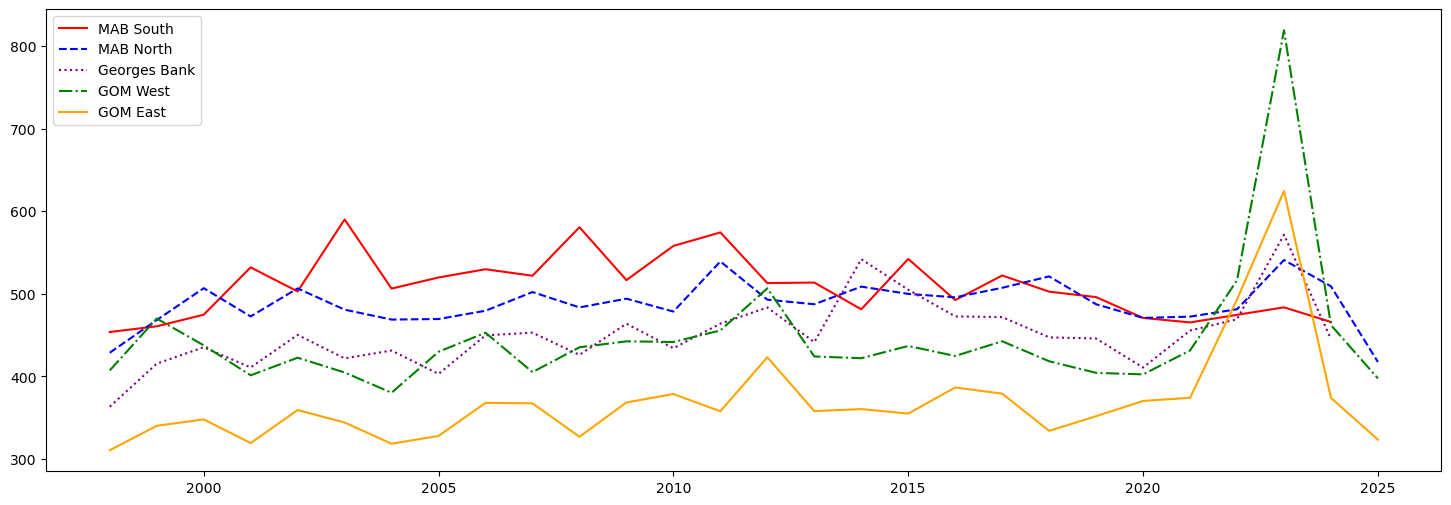

In [78]:
fig = plt.figure(figsize = (18,6))
plt.plot(summary_MABS['Year'],summary_MABS['Total integrated chl'],c='red',label='MAB South')
plt.plot(summary_MABN['Year'],summary_MABN['Total integrated chl'],c='blue',label='MAB North',linestyle='dashed')
plt.plot(summary_GB['Year'],summary_GB['Total integrated chl'],c='purple',label='Georges Bank',linestyle='dotted')
plt.plot(summary_GOMW['Year'],summary_GOMW['Total integrated chl'],c='green',label='GOM West',linestyle='-.')
plt.plot(summary_GOME['Year'],summary_GOME['Total integrated chl'],c='orange',label='GOM East')
plt.legend()

Text(0.5, 0, 'Year')

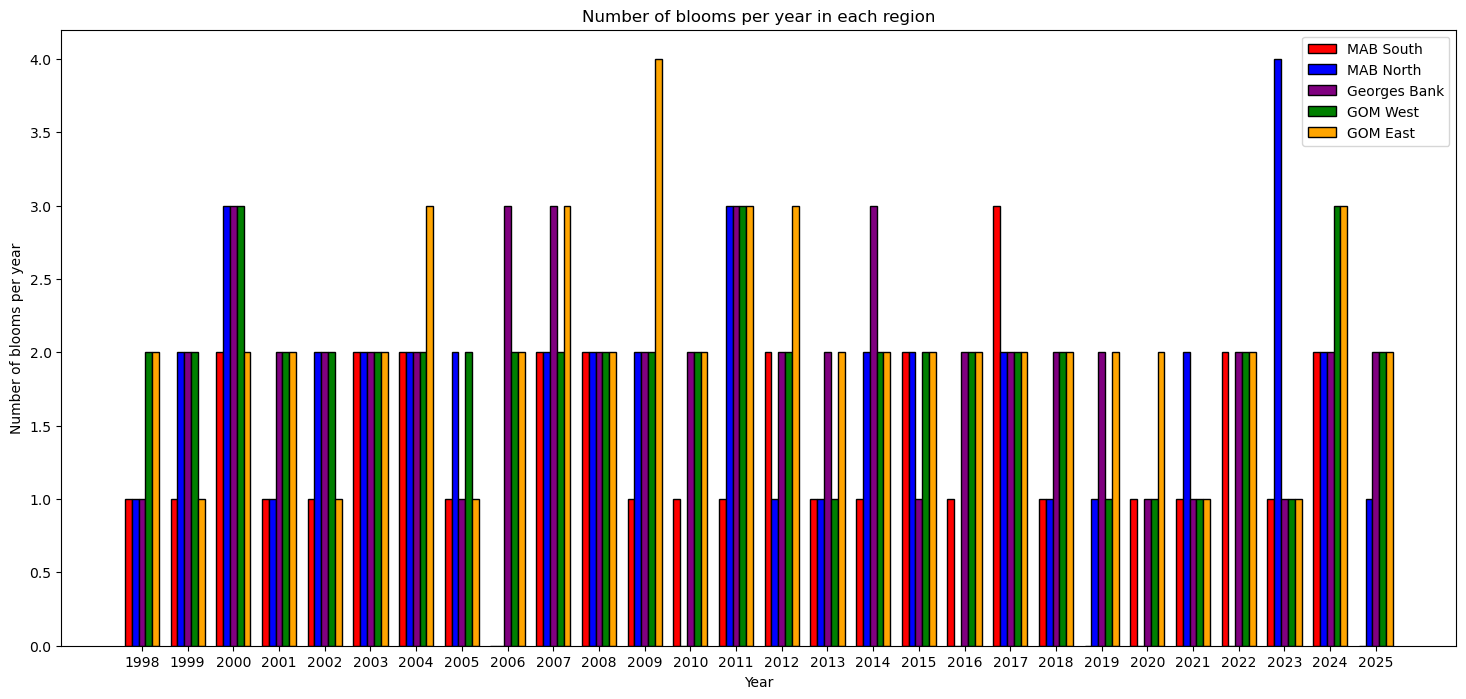

In [102]:
fig, ax = plt.subplots(figsize=(18,8))
width=0.15
x=summary_MABS['Year']
ax.bar(x-2*width,summary_MABS['Number of blooms'],color='red',label='MAB South',edgecolor='black',width=0.15)
ax.bar(x-width,summary_MABN['Number of blooms'],color='blue',label='MAB North',edgecolor='black',width=0.15)
ax.bar(x,summary_GB['Number of blooms'],color='purple',label='Georges Bank',edgecolor='black',width=0.15)
ax.bar(x+width,summary_GOMW['Number of blooms'],color='green',label='GOM West',edgecolor='black',width=0.15)
ax.bar(x+2*width,summary_GOME['Number of blooms'],color='orange',label='GOM East',edgecolor='black',width=0.15)
ax.set_xticks(x)
ax.legend()
ax.set_title("Number of blooms per year in each region")
ax.set_ylabel("Number of blooms per year")
ax.set_xlabel("Year")

In [ ]:
fig = plt.figure(figsize = (18,6))
plt.scatter(bloom_MABS['Year'],bloom_MABS['Integrated chl-a (mg/m^3 * day)'],c='red',label='MAB South')
#plt.scatter(bloom_MABN['Year'],bloom_MABN['Start DOY'],c='blue',label='MAB North',marker='^')
#plt.scatter(bloom_GB['Year'],bloom_GB['Start DOY'],c='purple',label='Georges Bank',marker='d')
#plt.scatter(bloom_GOMW['Year'],bloom_GOMW['Start DOY'],c='green',label='GOM West',marker='*')
#plt.scatter(bloom_GOME['Year'],bloom_GOME['Start DOY'],c='orange',label='GOM East',marker='s')
plt.legend()

In [236]:
csv_data = [bloom_MABS,bloom_MABN,bloom_GB,bloom_GOMW,bloom_GOME]
titles = ["Middle Atlantic Bight South", "Middle Atlantic Bight North", "Georges Bank", "Gulf of Maine West", "Gulf of Maine East"]
for x in range(5):
    data = csv_data[x]
    data['Start date day']=pd.to_datetime(data['Start date(threshold)'])
    data['End date day']=pd.to_datetime(data['End date (threshold)'])
    data['Start date']=data['Start date day'].dt.strftime('%m/%d/%Y')
    data['End date']=data['End date day'].dt.strftime('%m/%d/%Y')
    fig = px.timeline(
        data,
        x_start="Start date day",
        x_end="End date day",
        y="Bloom ID",
        color = "Duration above the threshold",
        title=f"Bloom Gantt Chart {titles[x]}",
        hover_data={
            "Start date":True,
            "End date":True,
            "Start date day": False,
            "End date day": False
        }
    )
    fig.update_xaxes(
        dtick="M12",
        tickformat="%Y",
        ticklabelmode="period"
    )
    fig.show()
    fig.write_html(rf"C:\Users\grace.davis\Documents\GitHub\phytoplankton_Hollings_project\Figures\{titles[x]}_threshold_Gantt_Chart.html")

In [238]:
csv_data = [bloom_MABS,bloom_MABN,bloom_GB,bloom_GOMW,bloom_GOME]
titles = ["Middle Atlantic Bight South", "Middle Atlantic Bight North", "Georges Bank", "Gulf of Maine West", "Gulf of Maine East"]
for x in range(5):
    data = csv_data[x]
    fig = px.scatter(
        data,
        x='Year',
        y=["Start DOY (threshold)", "End DOY (threshold)"],
        #trendline="ols",
        title= f"Trends in Bloom Start and End DOY in {titles[x]}",
        labels={"value": "Day of Year", "variable": "Metric"}
    )
    fig.update_xaxes(
        dtick="M12",
        tickformat="%Y",
        ticklabelmode="period"
    )
    fig.show()
    fig.write_html(rf"C:\Users\grace.davis\Documents\GitHub\phytoplankton_Hollings_project\Figures\{titles[x]}_DOY_threshold_Scatter.html")
#results = px.get_trendline_results(fig)
#print(results.px_fit_results.iloc[0].summary())